# Imbalanced Binary Classification

Today, we’re exploring **imbalanced binary classification**, focusing on detecting rare fraudulent transactions in a dataset where non-fraudulent transactions vastly outnumber the fraudulent ones. In imbalanced datasets, standard models often struggle to identify minority class instances. We’ll explore techniques to improve our model’s ability to detect fraudulent transactions.

In [ ]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# Imbalanced-learn library for handling imbalance
from imblearn.over_sampling import RandomOverSampler

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Load and Explore the Data

In [ ]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Credircardtransactions/')
dataset_path = data_path/'creditcard.csv'

# get the dataset
df = pd.read_csv(dataset_path)
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df['Class'].value_counts(dropna=False, normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Features Explanation:

* **Time:** Seconds elapsed between each transaction and the first transaction.
* **V1-V28:** Result of a PCA Dimensionality reduction to protect user identities and sensitive features.
* **Amount:** Transaction amount.
* Class: Target variable (0 for non-fraudulent, 1 for fraudulent transactions).

## Check for Missing Values

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Class Distribution

In [ ]:
# Count the number of occurrences of each class
class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


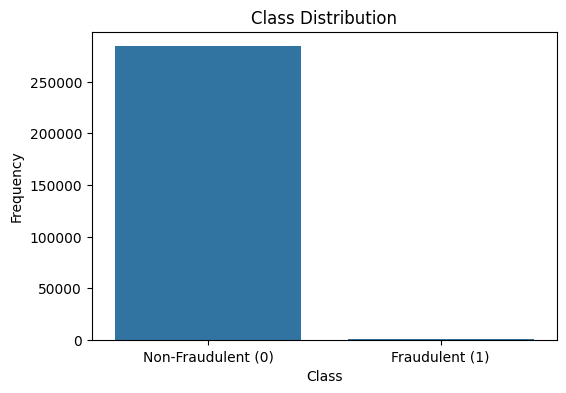

In [ ]:
# Plot the class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks([0,1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.show()

Observation: The dataset is highly imbalanced with the minority class (fraudulent transactions) making up a very small percentage of the data.

# Data Preprocessing


### Separate Features and Target Variable

In [ ]:
# Features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

### Split into Training and Testing Sets

In [ ]:
# Stratified splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Feature Scaling

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])


# Baseline Model

We'll start by training a logistic regression model without addressing the class imbalance to observe its performance.

### Train the Model

In [ ]:
# Initialize the model
model = LogisticRegression(max_iter=100, random_state=42)

# Train the model
model.fit(X_train, y_train)


LogisticRegression(random_state=42)

### Evaluate the Model

In [ ]:
# Predictions on the test set
y_pred = model.predict(X_test)

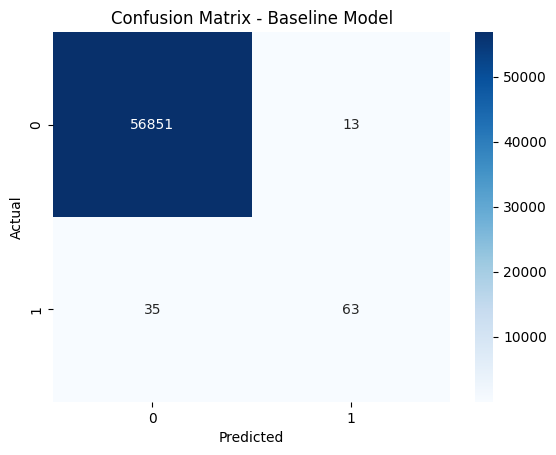

Classification Report - Baseline Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print('Classification Report - Baseline Model:\n')
print(classification_report(y_test, y_pred))


**Observation:** The model predicts almost all transactions as non-fraudulent due to class imbalance, resulting in poor detection of fraudulent transactions.

# Handling Class Imbalance

We'll use Random OverSampling to balance the class distribution by duplicating samples from the minority class.

In [ ]:
# Initialize the oversampler
ros = RandomOverSampler(random_state=42)

# Resample the training data
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)


In [ ]:
# New class distribution
print('Resampled dataset shape:', pd.Series(y_resampled).value_counts())

Resampled dataset shape: Class
0    227451
1    227451
Name: count, dtype: int64


## Train the Model on Resampled Data

In [ ]:
# Initialize the model
model_resampled = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model_resampled.fit(X_resampled, y_resampled)


LogisticRegression(max_iter=1000, random_state=42)

## Adjusting Class Weights

Alternatively, we can set class_weight='balanced' in our logistic regression model to penalize misclassification of the minority class more.

In [ ]:
# Initialize the model with balanced class weights
model_weighted = LogisticRegression(
    class_weight='balanced', max_iter=100, random_state=42
)

# Train the model
model_weighted.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

# Model Evaluation

## Evaluate the Resampled Model

In [ ]:
# Predictions on the test set
y_pred_resampled = model_resampled.predict(X_test)

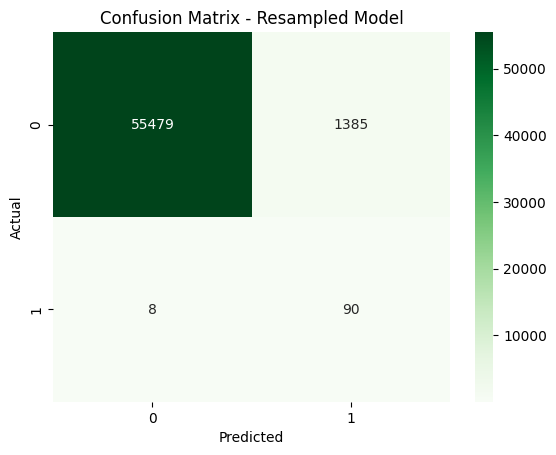

Classification Report - Resampled Model:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
# Confusion Matrix
cm_resampled = confusion_matrix(y_test, y_pred_resampled)
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Resampled Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print('Classification Report - Resampled Model:\n')
print(classification_report(y_test, y_pred_resampled))


## Evaluate the Weighted Model

In [ ]:
# Predictions on the test set
y_pred_weighted = model_weighted.predict(X_test)


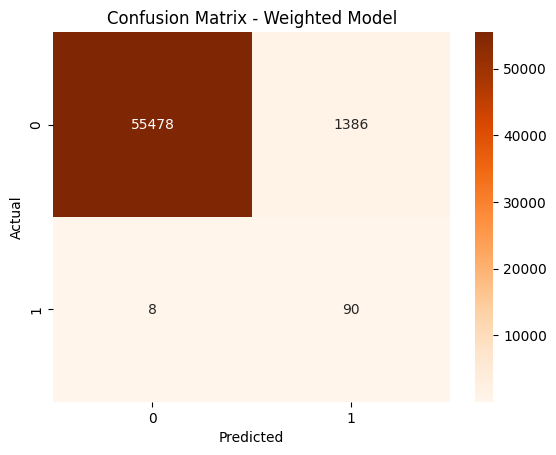

Classification Report - Weighted Model:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
# Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Weighted Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print('Classification Report - Weighted Model:\n')
print(classification_report(y_test, y_pred_weighted))


## Compare ROC Curves

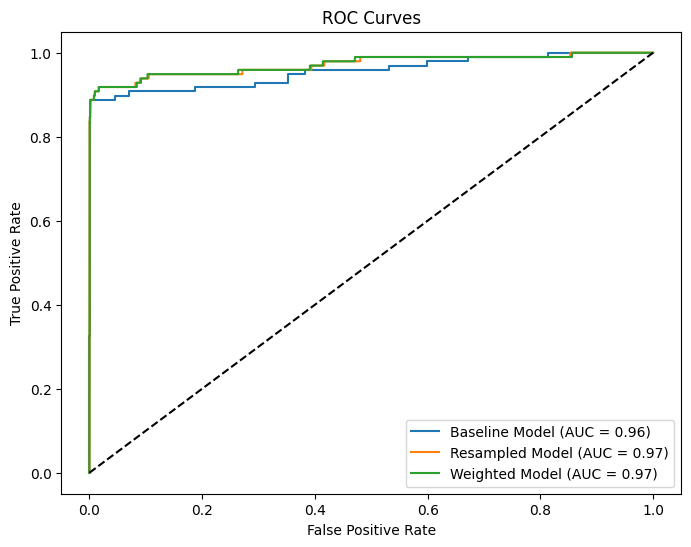

In [ ]:
# Probabilities for ROC curves
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_prob_resampled = model_resampled.predict_proba(X_test)[:, 1]
y_pred_prob_weighted = model_weighted.predict_proba(X_test)[:, 1]

# Compute ROC curves and AUC scores
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

fpr_resampled, tpr_resampled, _ = roc_curve(y_test, y_pred_prob_resampled)
roc_auc_resampled = roc_auc_score(y_test, y_pred_prob_resampled)

fpr_weighted, tpr_weighted, _ = roc_curve(y_test, y_pred_prob_weighted)
roc_auc_weighted = roc_auc_score(y_test, y_pred_prob_weighted)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Baseline Model (AUC = %0.2f)' % roc_auc)
plt.plot(fpr_resampled, tpr_resampled, label='Resampled Model (AUC = %0.2f)' % roc_auc_resampled)
plt.plot(fpr_weighted, tpr_weighted, label='Weighted Model (AUC = %0.2f)' % roc_auc_weighted)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


**Observation**: Both the resampled and weighted models show improved performance in detecting fraudulent transactions compared to the baseline model.

# Cross-Validated ROC AUC and PR Curves

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Initialize the logistic regression model with class weights
model_weighted_cv = LogisticRegression(
    class_weight='balanced', max_iter=100, random_state=42
)

# Compute cross-validated ROC AUC scores
roc_auc_scores = cross_val_score(
    model_weighted_cv, X, y, cv=skf, scoring='roc_auc', n_jobs=-1
)

print('Cross-Validated ROC AUC Scores (Logistic Regression):', roc_auc_scores)
print('Mean ROC AUC Score:', roc_auc_scores.mean())


Cross-Validated ROC AUC Scores (Logistic Regression): [0.98753801 0.98198719 0.97802021 0.97149773 0.96639919]
Mean ROC AUC Score: 0.9770884653622864


# Cross-Validated Precision-Recall Curves

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def cross_val_pr_curve(model, X, y, cv):
    tprs = []
    aucs = []
    mean_recall = np.linspace(0, 1, 100)

    precision_list = []
    recall_list = []
    average_precision_list = []

    for train_index, test_index in cv.split(X, y):
        # Split the data
        X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

        # Oversample the training data
        X_res_cv, y_res_cv = ros.fit_resample(X_train_cv, y_train_cv)

        # Fit the model
        model.fit(X_res_cv, y_res_cv)

        # Predict probabilities
        y_probas = model.predict_proba(X_test_cv)[:, 1]

        # Compute Precision-Recall curve
        precision, recall, _ = precision_recall_curve(y_test_cv, y_probas)
        average_precision = average_precision_score(y_test_cv, y_probas)

        precision_list.append(precision)
        recall_list.append(recall)
        average_precision_list.append(average_precision)

    return precision_list, recall_list, average_precision_list


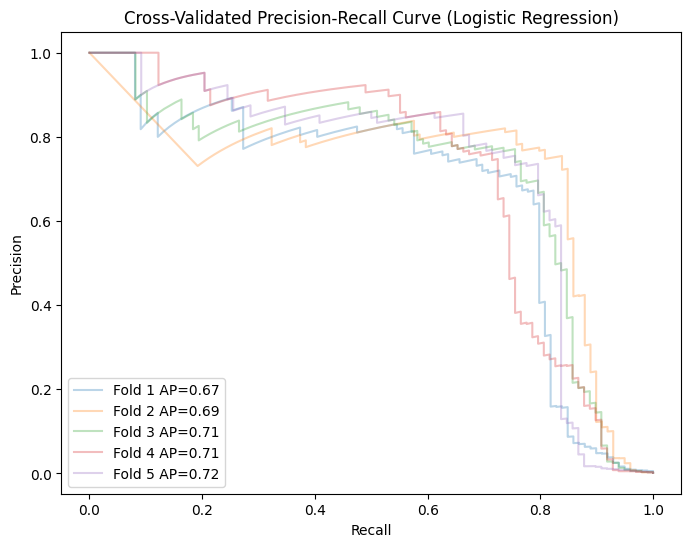

In [ ]:
# Get cross-validated precision-recall data for Logistic Regression
precision_list_lr, recall_list_lr, average_precision_list_lr = cross_val_pr_curve(
    model_weighted_cv, X, y, skf
)

# Plot the Precision-Recall curves
plt.figure(figsize=(8,6))

for i in range(len(precision_list_lr)):
    plt.plot(recall_list_lr[i], precision_list_lr[i], alpha=0.3,
             label='Fold %d AP=%.2f' % (i+1, average_precision_list_lr[i]))

plt.title('Cross-Validated Precision-Recall Curve (Logistic Regression)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()


In [ ]:
# Logistic Regression Average Precision
mean_ap_lr = np.mean(average_precision_list_lr)
print('Mean Average Precision Score (Logistic Regression):', mean_ap_lr)


Mean Average Precision Score (Logistic Regression): 0.7019419950382493


# Conclusion

- **Random Oversampling:** Helps balance the dataset by
duplicating minority class samples, improving the model’s ability to detect
fraud.
- **Class Weight Adjustment:** Offers an alternative by directly
penalizing errors on the minority class, also improving detection without oversampling.
- **Evaluation Metrics:** ROC and PR curves provide insights
into the model’s ability to handle class imbalance.
- **Cross-Validation:** Ensures robust performance estimates by validating across multiple data
splits.